In [1]:
### accuracy test 
import os
import pandas as pd
import cv2

eyes = pd.DataFrame(columns = ['path', 'class'])
for dir in os.listdir('MMU-Iris-Database'):
    try:
        for photo in os.listdir(f'MMU-Iris-Database/{dir}/left')[0:2]:
            if photo.endswith('.bmp'):
                eyes = pd.concat([eyes, pd.DataFrame([[f'MMU-Iris-Database/{dir}/left/{photo}', dir + 'left']], columns = ['path', 'class'])], ignore_index=True)
        for photo in os.listdir(f'MMU-Iris-Database/{dir}/right')[0:2]:
            if photo.endswith('.bmp'):
                eyes = pd.concat([eyes, pd.DataFrame([[f'MMU-Iris-Database/{dir}/right/{photo}', dir + 'right']], columns = ['path', 'class'])], ignore_index=True)
                
    except Exception as e:
        print(f"Error processing {dir}: {e}")
        continue
        
#convert classes to numbers
eyes['class'] = eyes['class'].astype('category')
eyes['class'] = eyes['class'].cat.codes
eyes['class'] = eyes['class'].astype('int')

Error processing .DS_Store: [Errno 20] Not a directory: 'MMU-Iris-Database/.DS_Store/left'
Error processing ReadMe.txt: [Errno 20] Not a directory: 'MMU-Iris-Database/ReadMe.txt/left'


In [2]:
from funcs import *
def are_same_eyes(path1, path2):
    image_raw1 = cv2.imread(path1, 0)
    image_raw2 = cv2.imread(path2, 0)
    
    image_center_pupil1, (x1, y1), radius_pupil1 = get_pupil(image_raw1)
    image_center_iris1, (x1, y1), radius_iris1 = get_iris(image_raw1, x1, y1, radius_pupil1)
    
    image_center_pupil2, (x2, y2), radius_pupil2 = get_pupil(image_raw2)
    image_center_iris2, (x2, y2), radius_iris2 = get_iris(image_raw2, x2, y2, radius_pupil2)
    
    unwrapped1 = unwrap_iris_with_masks(
        image=image_raw1,
        x=x1,
        y=y1,
        r_pupil=radius_pupil1,
        r_iris=radius_iris1,
        height=256,
        width=2048
    )
    unwrapped2 = unwrap_iris_with_masks(
        image=image_raw2,
        x=x2,
        y=y2,
        r_pupil=radius_pupil2,
        r_iris=radius_iris2,
        height=256,
        width=2048
    )
    code1 = generate_iris_code(unwrapped1)
    code2 = generate_iris_code(unwrapped2)
    return hamming_distance(code1, code2) < 0.229


In [3]:
#confusion matrix
n_classes = len(eyes['class'].unique())
confusion_matrix = np.zeros((n_classes, n_classes), dtype=int)
hit =0
for i in range(len(eyes)):
    for j in range(i + 1, len(eyes)):  
        print(f"Comparing {eyes['path'].iloc[i]} and {eyes['path'].iloc[j]}") 
        try:
            if are_same_eyes(eyes['path'].iloc[i], eyes['path'].iloc[j]):
                confusion_matrix[eyes['class'].iloc[i]][eyes['class'].iloc[j]] += 1
                confusion_matrix[eyes['class'].iloc[j]][eyes['class'].iloc[i]] += 1
                if eyes['class'].iloc[i] == eyes['class'].iloc[j]:
                    hit += 1
            else:
                if eyes['class'].iloc[i] != eyes['class'].iloc[j]:
                    hit += 1
        except Exception as e:
            print(f"Error comparing {eyes['path'][i]} and {eyes['path'][j]}: {e}")
            continue
                
#plot


Comparing MMU-Iris-Database/32/left/salal1.bmp and MMU-Iris-Database/32/left/salal2.bmp
Comparing MMU-Iris-Database/32/left/salal1.bmp and MMU-Iris-Database/32/right/salar4.bmp
Comparing MMU-Iris-Database/32/left/salal1.bmp and MMU-Iris-Database/32/right/salar5.bmp
Comparing MMU-Iris-Database/32/left/salal1.bmp and MMU-Iris-Database/35/left/suzailil3.bmp
Comparing MMU-Iris-Database/32/left/salal1.bmp and MMU-Iris-Database/35/left/suzailil2.bmp
Comparing MMU-Iris-Database/32/left/salal1.bmp and MMU-Iris-Database/35/right/suzailir5.bmp
Comparing MMU-Iris-Database/32/left/salal1.bmp and MMU-Iris-Database/35/right/suzailir4.bmp
Comparing MMU-Iris-Database/32/left/salal1.bmp and MMU-Iris-Database/34/left/sitil5.bmp
Comparing MMU-Iris-Database/32/left/salal1.bmp and MMU-Iris-Database/34/left/sitil4.bmp
Comparing MMU-Iris-Database/32/left/salal1.bmp and MMU-Iris-Database/34/right/sitir3.bmp
Comparing MMU-Iris-Database/32/left/salal1.bmp and MMU-Iris-Database/34/right/sitir2.bmp
Comparing MMU-

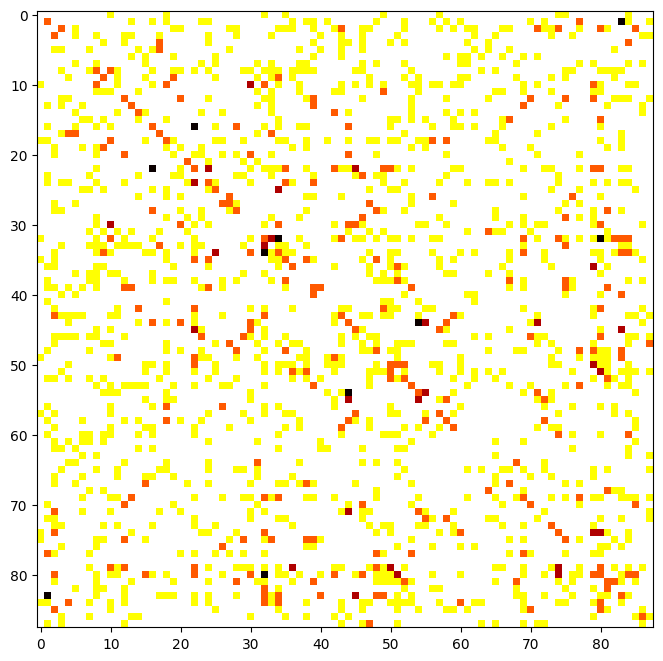

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(confusion_matrix, cmap='hot_r', interpolation='nearest')

In [5]:
print(hit / (len(eyes) * (len(eyes) - 1) / 2))

0.9066082511865644
